# **Feature Construction in Machine Learning**

**Feature Construction** (also known as Feature Engineering from scratch) is the process of manually combining, transforming, or multiplying existing variables in a dataset to create an entirely new feature. The goal is to isolate and expose a hidden relationship or signal in the data, making it easier for a machine learning algorithm to learn the underlying patterns.

---

## 1. Core Mechanics: Why It Works

Machine learning algorithms—especially linear ones—evaluate features individually or along simple linear combinations. They often struggle to naturally uncover hidden ratios, physical spaces, or mathematical interactions between columns unless you explicitly map them out.

*   **The Conceptual Approach:** Instead of forcing a model to independently figure out how two columns interact, you build a compound feature that represents that interaction directly. 

For example, if you have a real estate dataset with `House_Price`, `Total_Square_Feet`, and `Number_of_Bedrooms`, a model might struggle to determine value efficiency. By constructing a new feature like `Price_per_Square_Foot`, you provide an explicit, highly predictive signal.


*   **Mathematical Operations:** Feature construction is typically achieved using standard mathematical operations across columns:

    *   **Ratios / Fractions:** Dividing one feature by another (e.g., `Total_Debt` / `Total_Income` = `Debt_to_Income_Ratio`).
    *   **Products / Interactions:** Multiplying columns together (e.g., `Click_Rate` × `Total_Impressions` = `Estimated_Conversions`).
    *   **Sums / Aggregations:** Adding multiple related fields together (e.g., `Math_Score` + `Reading_Score` + `Science_Score` = `Total_Academic_Score`).

---

## 2. Common Real-World Use Cases

*   **E-Commerce & Retail:** Combining `Quantity_Purchased` and `Unit_Price` to construct a `Total_Order_Value` feature.

*   **Geospatial Analysis:** Using physics formulas on `Latitude` and `Longitude` coordinate columns to construct a new `Distance_to_Nearest_Warehouse` column.

*   **Financial Risk Modeling:** Dividing monthly credit card balances by total credit limits to engineer a `Credit_Utilization_Rate` column.

---

## 3. Advantages (Benefits)

*   **Boosts Model Performance:** It directly improves accuracy, especially for simpler linear algorithms (Linear/Logistic Regression) that cannot natively calculate non-linear feature interactions on their own.

*   **Introduces Domain Expertise:** It allows data scientists to inject specific real-world industry knowledge (like banking ratios or healthcare indices) directly into the data matrix, guiding the model toward logical patterns.

*   **Reduces Model Complexity:** A single, well-constructed compound feature can often replace the need for an overly deep decision tree or a complex neural network, leading to faster training times.

---

## 4. Disadvantages and Risks (Why to Avoid)

*   **The Risk of Overfitting:** If you construct hundreds of arbitrary mathematical combinations without an underlying logical or physical reason, your model may pick up on purely accidental patterns in your training data, hurting its ability to generalize to new data.

*   **Multicollinearity Issues:** Because the newly constructed feature is directly derived from existing columns, it will share a high linear correlation with them. If you keep both the original features and the constructed feature in a Linear Regression pipeline, it can destabilize your model's coefficient weights.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Importing Dataset
df = pd.read_csv("../data/titanic.csv", usecols=['Age', 'Pclass', 'SibSp', 'Parch', 'Survived'])
df.sample(5)

,Survived,Pclass,Age,SibSp,Parch
172,1,3,1.0,1,1
435,1,1,14.0,1,2
258,1,1,35.0,0,0
527,0,1,NaN,0,0
107,1,3,NaN,0,0


In [21]:
# Dropping the missing data to compare 
df.dropna(inplace=True)
df.sample(5)

,Survived,Pclass,Age,SibSp,Parch
871,1,1,47.0,1,1
882,0,3,22.0,0,0
706,1,2,45.0,0,0
236,0,2,44.0,1,0
27,0,1,19.0,3,2


In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Splitting the data into features and target variable
X = df.drop('Survived', axis=1)
y = df['Survived']


# Training Model and Cross val score
model = LogisticRegression()

cross_val = cross_val_score(model, X, y, scoring='accuracy', cv=20)
print(f" Mean Accuracy: {np.mean(cross_val)}")


 Mean Accuracy: 0.6933333333333332


In [23]:
# From the data We can construct a new feature called 'Family' by combining SibSp and Parch

X['Family'] = X['SibSp'] + X['Parch'] + 1 # Adding 1 to include the individual in the family count
X.sample(5)

,Pclass,Age,SibSp,Parch,Family
9,2,14.0,1,0,2
875,3,15.0,0,0,1
80,3,22.0,0,0,1
600,2,24.0,2,1,4
496,1,54.0,1,0,2


In [25]:
# Custom Function to classify as alone(0), small family(1) or large family(2)

def classify_family(family):
    
    if family == 1:
        return 0 # Alone
    elif family > 1 and family<=4:
        return 1 # Small Family
    else:
        return 2 # Large Family

# Apply Custom Function to the DataFrame 
X['Family_Type'] = X['Family'].apply(classify_family)
X.sample(5)

,Pclass,Age,SibSp,Parch,Family,Family_Type
675,3,18.0,0,0,1,0
21,2,34.0,0,0,1,0
183,2,1.0,2,1,4,1
676,3,24.5,0,0,1,0
269,1,35.0,0,0,1,0


In [26]:
# Removing Some of the same meaning Columns 
X.drop(columns=['SibSp', 'Parch', 'Family'], inplace=True)
X.sample(5)

,Pclass,Age,Family_Type
315,3,26.0,0
848,2,28.0,1
781,1,17.0,1
233,3,5.0,2
515,1,47.0,0


In [ ]:
# Model Evaluation on Feature Construction
cross_val = cross_val_score(model, X, y, scoring='accuracy', cv=20)
print(f" Mean Accuracy: {np.mean(cross_val)}")

# From the above results we can see that our model is performing well with an accuracy of around 70%.
# This indicates that our feature construction has been effective.

 Mean Accuracy: 0.7003174603174602



# **Feature Splitting in Machine Learning**

**Feature Splitting** is a preprocessing and feature-engineering technique where a single, complex column is broken down into multiple, distinct individual features. It is the exact operational opposite of Feature Construction. It is used when a single text string or composite data type packs multiple independent pieces of information together.

---

## 1. Core Mechanics: Why It Works

Machine learning algorithms require clean, structured, and homogenous inputs. If a single column contains a blend of names, numbers, dates, or codes mashed into a single text string, an algorithm cannot isolate the individual components to find patterns.

*   **The Extraction Approach:** Feature splitting unpacks composite strings using delimiters (like spaces, dashes, or commas) or regular expressions (regex). By segregating the raw cell into multiple dedicated child columns, you allow the machine learning model to evaluate each specific attributes' weights independently.

*   **Common Targets for Splitting:**

    *   **Full Names:** Splitting `"Dr. John Doe"` into `Salutation` (`"Dr."`), `First_Name` (`"John"`), and `Last_Name` (`"Doe"`).
    *   **Address Strings:** Unpacking `"New York, NY, 10001"` into separate columns for `City`, `State`, and `Zip_Code`.
    *   **Complex Product Codes / SKUs:** Breaking a manufacturing code like `"ELEC-SONY-4K-2026"` into `Category` (`"ELEC"`), `Brand` (`"SONY"`), `Resolution` (`"4K"`), and `Release_Year` (`2026`).

---

## 2. Special Category: Date & Time Splitting

The most impactful variant of feature splitting in data science involves **Datetime** stamps. A raw timestamp like `"2026-09-01 10:58:00"` is entirely unreadable to a standard machine learning model. 

By applying feature splitting, you extract multiple rich numerical and categorical features from that single point:
*   `Year` (e.g., `2026`)
*   `Month` (e.g., `9`)
*   `Day_of_Month` (e.g., `1`)
*   `Day_of_Week` (e.g., `Tuesday` or `1` as an integer index)
*   `Hour` (e.g., `10`)
*   `Is_Weekend` (e.g., `0` for False, `1` for True)

---

## 3. Advantages (Benefits)

*   **Exposes Unstructured Signals:** It converts messy, semi-structured text data into highly structured, numerical, or categorical columns that machine learning algorithms can immediately process.

*   **Enables Target Encoding and Grouping:** Once fields are split (e.g., isolating the `State` from a full address string), you can calculate aggregate statistics or apply **One-Hot Encoding** to map geographical variations precisely.

*   **Improves Model Interpretability:** It makes your final model significantly more explainable. Instead of a black-box model saying a composite SKU code is predictive, it can explicitly show that the `Brand` component holds the predictive power.

---

## 4. Disadvantages and Risks (Why to Avoid)

*   **Cardianality Explosion:** If you split a column into many distinct category strings (like extracting individual words from a description field), you can accidentally trigger high cardinality, causing your feature space to balloon when encoded.

*   **Vulnerability to Bad Formatting:** Feature splitting relies heavily on absolute formatting consistency. If your string splitter expects a dash delimiter (`-`) but a human enters data using a slash (`/`), the splitting logic will fail, creating missing values (`NaN`) or corrupted shifts in your data rows.



In [29]:
df = pd.read_csv('../data/titanic.csv')
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
768,769,0,3,"Moran, Mr. Daniel J",male,NaN,1,0,371110,24.15,NaN,Q
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.00,B28,NaN
49,50,0,3,"Arnold-Franchi, Mrs. Josef (Josefine Franchi)",female,18.0,1,0,349237,17.80,NaN,S
690,691,1,1,"Dick, Mr. Albert Adrian",male,31.0,1,0,17474,57.00,B20,S
427,428,1,2,"Phillips, Miss. Kate Florence (""Mrs Kate Louis...",female,19.0,0,0,250655,26.00,NaN,S


In [37]:
# We are splitting the feature called 'Name' to extract the title of the individual. This can be useful as a feature for our model.
df['Title'] = df['Name'].str.split(',', expand=True)[1].str.split(' ', expand=True)[1]


In [38]:
df[['Title', 'Name']]

,Title,Name
0,Mr.,"Braund, Mr. Owen Harris"
1,Mrs.,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,Miss.,"Heikkinen, Miss. Laina"
3,Mrs.,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,Mr.,"Allen, Mr. William Henry"
...,...,...
886,Rev.,"Montvila, Rev. Juozas"
887,Miss.,"Graham, Miss. Margaret Edith"
888,Miss.,"Johnston, Miss. Catherine Helen ""Carrie"""
889,Mr.,"Behr, Mr. Karl Howell"


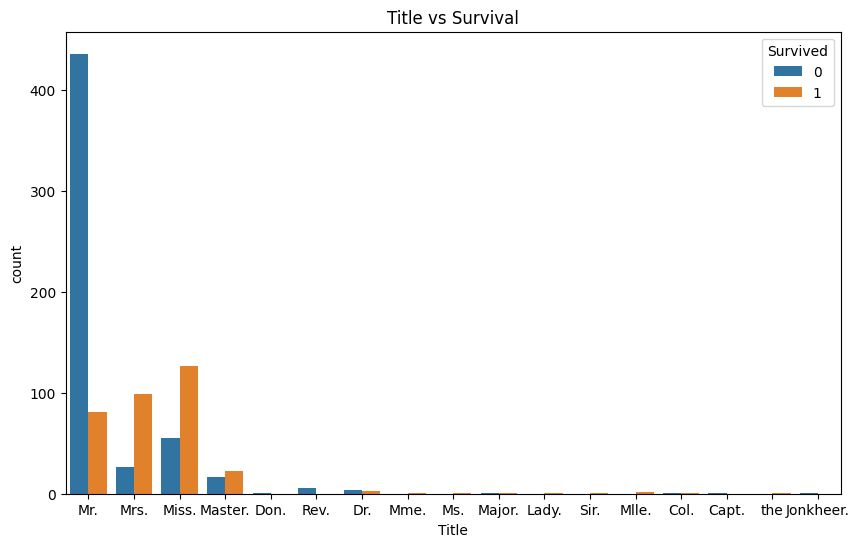

In [42]:
# Analyzing the Title Column to see how it affects the survival rate of passengers.
plt.figure(figsize=(10, 6))
sns.countplot(x='Title', hue='Survived', data=df)
plt.title('Title vs Survival')
plt.show()

In [49]:
(df.groupby('Title')['Survived'].mean()).sort_values(ascending=False)
# Analyzing the Name Column to see how it affects the survival rate of passengers.

Title
the          1.000000
Mlle.        1.000000
Sir.         1.000000
Ms.          1.000000
Lady.        1.000000
Mme.         1.000000
Mrs.         0.792000
Miss.        0.697802
Master.      0.575000
Col.         0.500000
Major.       0.500000
Dr.          0.428571
Mr.          0.156673
Jonkheer.    0.000000
Rev.         0.000000
Don.         0.000000
Capt.        0.000000
Name: Survived, dtype: float64